In [12]:
import sys
!{sys.executable} -m pip install wordcloud

In [14]:
import urllib.request
from bs4 import BeautifulSoup
import re

# Fetch the Wikipedia Data Science page
url = "https://en.wikipedia.org/wiki/Data_science"
req = urllib.request.Request(
    url,
    headers={"User-Agent": "Mozilla/5.0 (compatible; DataScienceStudent/1.0)"}
)
response = urllib.request.urlopen(req)
html = response.read().decode("utf-8")

# Parse and extract plain text
soup = BeautifulSoup(html, "html.parser")

# Remove references, navboxes, and other clutter
for tag in soup(["script", "style", "sup", "table", "figure"]):
    tag.decompose()

# Get the main article text
text = soup.get_text()

# Clean up whitespace
text = re.sub(r'\s+', ' ', text).strip()

print("✓ Page fetched successfully")
print(f"Total characters: {len(text)}")
print("\nFirst 500 characters preview:")
print(text[:500])

✓ Page fetched successfully
Total characters: 21182

First 500 characters preview:
Data science - Wikipedia Jump to content Main menu Main menu move to sidebar hide Navigation Main pageContentsCurrent eventsRandom articleAbout WikipediaContact us Contribute HelpLearn to editCommunity portalRecent changesUpload fileSpecial pages Search Search Appearance Donate Create account Log in Personal tools Donate Create account Log in Contents move to sidebar hide (Top) 1 Foundations 2 Etymology Toggle Etymology subsection 2.1 Early usage 2.2 Modern usage 3 Data science and data analysis


In [16]:
from collections import Counter
import string

# Define stopwords — common words we want to ignore
stopwords = set([
    "the", "a", "an", "and", "or", "but", "in", "on", "at", "to", "for",
    "of", "with", "by", "from", "is", "are", "was", "were", "be", "been",
    "has", "have", "had", "it", "its", "this", "that", "as", "not", "be",
    "which", "who", "their", "they", "we", "he", "she", "you", "i", "also",
    "can", "more", "such", "about", "into", "than", "other", "used", "using",
    "may", "between", "through", "these", "after", "often", "use", "new",
    "data", "science"  # removing these since they'll dominate everything
])

# Tokenise — split into individual words
words = text.lower().split()

# Remove punctuation and short words
words = [w.strip(string.punctuation) for w in words]
words = [w for w in words if w.isalpha() and len(w) > 3 and w not in stopwords]

# Count frequencies
word_freq = Counter(words)

print("✓ Keywords extracted")
print(f"Unique words found: {len(word_freq)}")
print("\nTop 20 most frequent keywords:")
for word, count in word_freq.most_common(20):
    print(f"  {word:<20} {count}")

✓ Keywords extracted
Unique words found: 857

Top 20 most frequent keywords:
  statistics           24
  retrieved            15
  analysis             14
  information          14
  statistical          13
  computing            12
  issn                 12
  field                10
  research             10
  learning             10
  isbn                 10
  april                10
  knowledge            9
  october              9
  what                 8
  computer             8
  century              8
  scientist            7
  business             7
  ethics               7


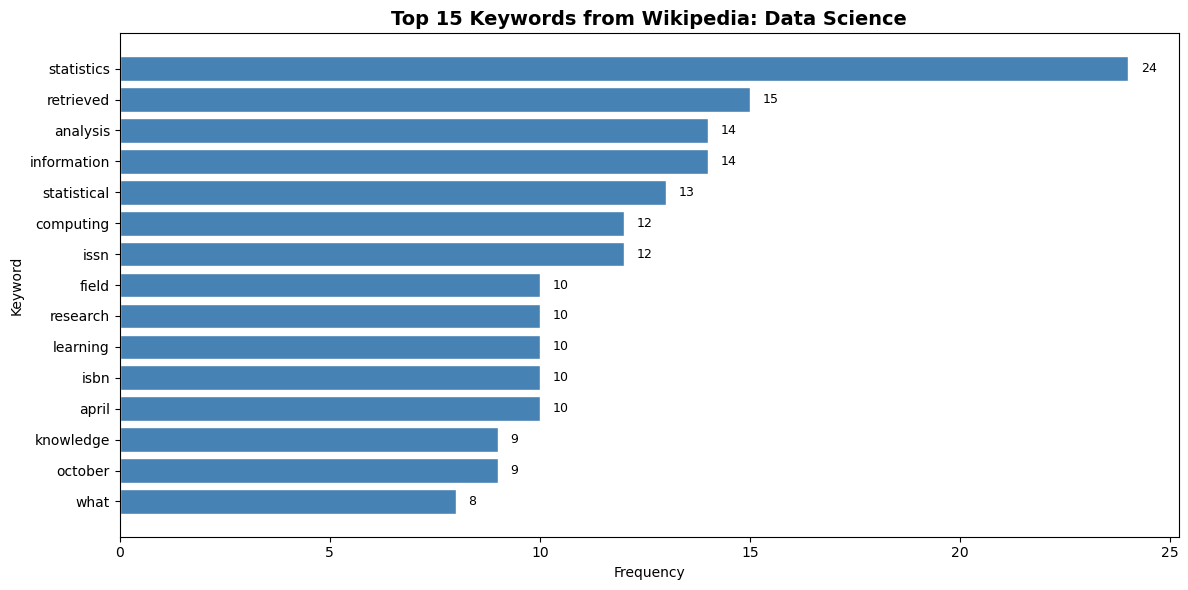

In [18]:
import matplotlib.pyplot as plt

# Get top 15 keywords
top_words = word_freq.most_common(15)
words_list  = [w[0] for w in top_words]
counts_list = [w[1] for w in top_words]

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(words_list[::-1], counts_list[::-1], color='steelblue', edgecolor='white')
ax.set_title("Top 15 Keywords from Wikipedia: Data Science", fontsize=14, fontweight='bold')
ax.set_xlabel("Frequency")
ax.set_ylabel("Keyword")
for bar, count in zip(bars, counts_list[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(count), va='center', fontsize=9)
plt.tight_layout()
plt.show()

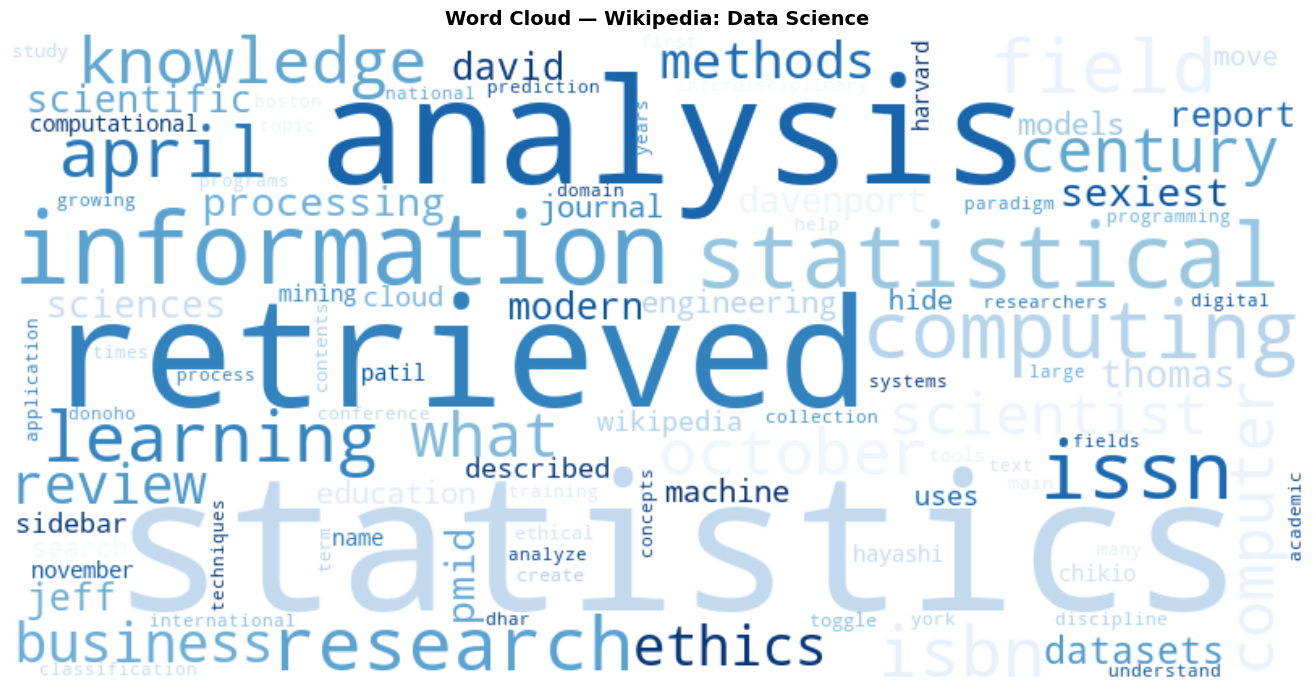

In [20]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Generate word cloud
wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Blues',
    max_words=100
).generate_from_frequencies(word_freq)

# Display
plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud — Wikipedia: Data Science", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()